cuda


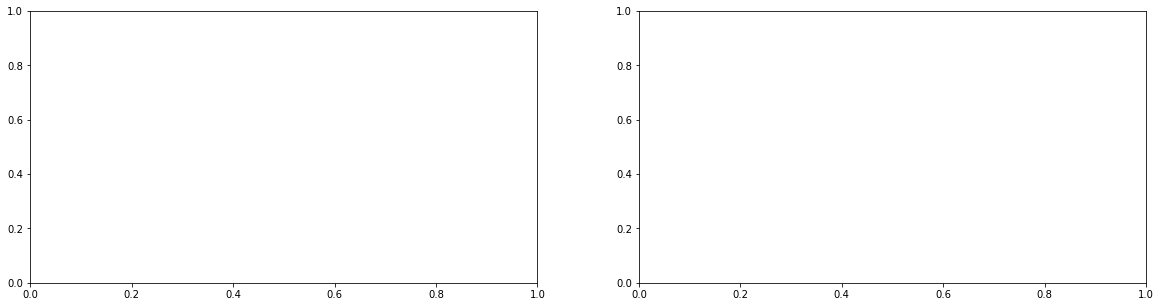

In [2]:
import os
import sys
import time
import copy
sys.path.append('../SLM/')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import numpy as np
import json
import math
import random

import fnmatch
import re
from itertools import product, groupby

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from tokenizers import Tokenizer

import models, init, train, measures
import importlib
# Reload the modules
importlib.reload( models)

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(device)

def collect(path, prefix, *keys):

    all_entries = os.listdir(path)
    matching_entries = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
#                 params = re.findall(r'_P(\d+)', ending)
#                 assert params, f'{entry}: trainsize p not found!'
                array = re.findall(r'_(\d+)', ending)
                matching_entries.append({
                    'ending': ending,
#                     'P': int(params[0]),
                    'seed': int(array[0])
                })
#     matching_entries.sort(key=lambda x: [x.get('P'), x.get('exp')])
    return matching_entries


def find_all(path, prefix, what, *keys):
    
    all_entries = os.listdir(path)
    params = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
                param = re.findall(what+r'(\d+)', ending)
                param = int(param[0])
                if param not in params:
                    params.append(param)
    params.sort()
    return params


def find_lowest(path, prefix, what, *keys):
    
    all_entries = os.listdir(path)
    params = []
    for entry in all_entries:

        if fnmatch.fnmatch(entry, prefix+'*'):

            check_keys = 1
            for key in keys:
                check_keys *= fnmatch.fnmatch(entry, '*'+key+'*')
            if check_keys:
                ending = re.sub(prefix, '', entry)
                param = re.findall(what+r'(\d+)', ending)
                param = int(param[0])
                if param not in params:
                    params.append(param)
    params.sort()
    return params[0]


def get_loss(path, prefix):

    loss_list = []

    p_list = find_all(path, prefix, 'P')
    print('training set sizes: ', p_list)

    for  p in p_list:

        bs = find_lowest(path, prefix, 'bs', f'P{p}_')
        print(f'P={p}, batch size={bs}')
        collection = collect( path, prefix, f'P{p}_', f'bs{bs}_')
        loss = []

        for entry in collection:
            try:
                results = torch.load(path+prefix+entry['ending'])
                print(p, results['best']['loss'])
                loss.append(results['best']['loss'])

            except:
                print(path+prefix+entry['ending']+f' not found.')


        print(f'{len(loss)} exps. , mean loss {torch.tensor(loss).mean()}')
        loss_list.append(torch.tensor(loss))
    return loss_list


fig, ax = plt.subplots(1, 2, figsize=(20,5.0))

# $P=2^{18}$

768 1 1e-4 2.0 tensor(3.9677) tensor(0.0200)
768 1 1e-4 4.0 tensor(3.9098) tensor(0.0149)
768 1 1e-4 8.0 tensor(3.9443) tensor(0.0103)
768 1 1e-4 16.0 tensor(3.9559) tensor(0.0168)
768 1 3e-4 2.0 tensor(3.8903) tensor(0.0049)
768 1 3e-4 4.0 tensor(3.8485) tensor(0.0090)
768 1 3e-4 8.0 tensor(3.9322) tensor(0.0169)
768 1 1e-3 2.0 tensor(3.9141) tensor(0.0138)
768 1 1e-3 4.0 tensor(3.9799) tensor(0.0344)
768 1 1e-3 8.0 tensor(4.0389) tensor(0.0137)
768 2 3e-4 2.0 tensor(3.9408) tensor(0.0092)
768 2 3e-4 4.0 tensor(3.8786) tensor(0.0200)
768 2 3e-4 8.0 tensor(3.9413) tensor(0.0053)
768 2 1e-3 2.0 tensor(3.9216) tensor(0.0189)
768 2 1e-3 4.0 tensor(3.9029) tensor(0.0302)
768 2 1e-3 8.0 tensor(4.0127) tensor(0.0203)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=2$)')

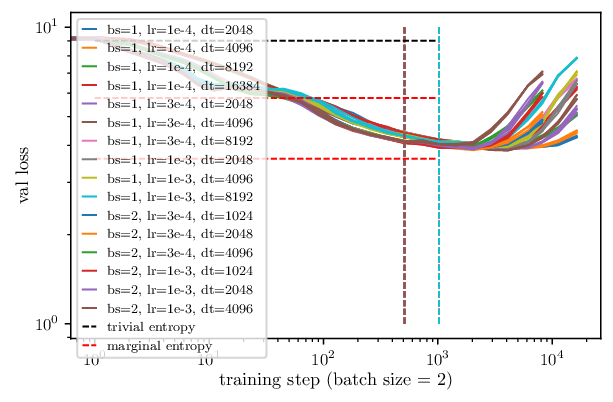

In [2]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 256
P = 262144
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 12
de = 768

bs = 1
lr = '1e-4'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 1
lr = '1e-4'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 1
lr = '1e-4'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 1
lr = '1e-4'
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 1
lr = '3e-4'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 1
lr = '3e-4'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 1
lr = '3e-4'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 1
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 1
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 1
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
lr = '3e-4'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
lr = '3e-4'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
lr = '3e-4'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
lr = '1e-3'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# $P=2^{20}$

768 1 3e-4 2.0 tensor(3.0887) tensor(0.0194)
768 1 3e-4 4.0 tensor(2.9552) tensor(0.0236)
768 1 1e-3 2.0 tensor(2.9732) tensor(0.0095)
768 1 1e-3 4.0 tensor(2.9143) tensor(0.0146)
768 2 3e-4 2.0 tensor(3.1625) tensor(0.0276)
768 2 3e-4 4.0 tensor(2.9787) tensor(0.0205)
768 2 3e-4 8.0 tensor(3.0243) tensor(0.0273)
768 2 1e-3 4.0 tensor(2.8971) tensor(0.0094)
768 2 1e-3 8.0 tensor(2.9764) tensor(0.0195)
768 4 3e-4 2.0 tensor(3.2627) tensor(0.0214)
768 4 3e-4 4.0 tensor(3.0559) tensor(0.0170)
768 4 3e-4 8.0 tensor(3.0846) tensor(0.0268)
768 4 1e-3 2.0 tensor(3.0370) tensor(0.0313)
768 4 1e-3 4.0 tensor(2.9035) tensor(0.0109)
768 4 1e-3 6.0 tensor(2.9833) tensor(0.0102)
768 4 1e-3 8.0 tensor(3.0008) tensor(0.0094)
768 8 1e-3 2.0 tensor(3.1852) tensor(0.0170)
768 8 1e-3 4.0 tensor(2.9737) tensor(0.0046)
768 8 1e-3 8.0 tensor(3.0105) tensor(0.0210)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=8$)')

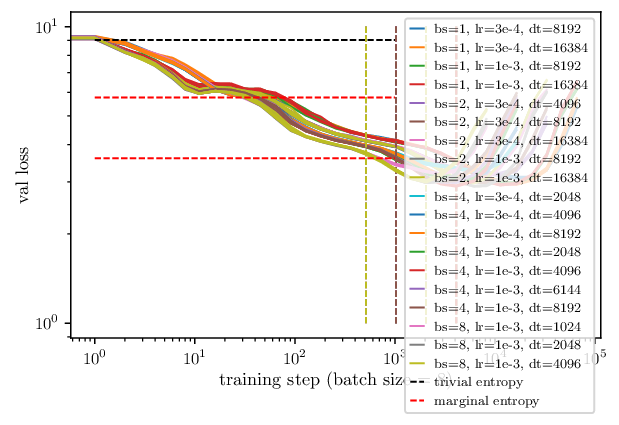

In [3]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 256
P = 1048576
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 12
de = 768

bs = 1
lr = '3e-4'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 1
lr = '3e-4'
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 1
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 1
lr = '1e-3'
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
lr = '3e-4'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
lr = '3e-4'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
lr = '3e-4'
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
lr = '1e-3'
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '3e-4'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '3e-4'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '3e-4'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-3'
dt = 6144
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 1024
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{20}$ : bs=2, lr=1e-3, dt=8192 (4 ep)

# $P=2^{22}$

In [ ]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 256
P = 4194304
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 12
de = 768

bs = 2
lr = '3e-4'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
lr = '3e-4'
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
lr = '3e-4'
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '3e-4'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '3e-4'
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '3e-4'
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-3'
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-3'
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '3e-4'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


bs = 8
lr = '3e-4'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '3e-4'
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '1e-3'
dt = 2048
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '1e-3'
dt = 4096
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '1e-3'
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{22}$ : bs=8, lr=1e-3, dt=8192 (4 ep)

# $P=2^{24}$

768 2 1e-4 2.0 tensor(1.8415) tensor(0.0121)
768 2 1e-4 4.0 tensor(1.7794) tensor(0.0157)
768 2 1e-4 8.0 tensor(1.8274) tensor(0.0207)
768 2 3e-4 2.0 tensor(1.7837) tensor(0.0081)
768 2 3e-4 4.0 tensor(1.7223) tensor(0.0019)
768 2 3e-4 8.0 tensor(1.7786) tensor(0.0073)
768 4 1e-4 2.0 tensor(1.8819) tensor(0.0054)
768 4 1e-4 4.0 tensor(1.8090) tensor(0.0159)
768 4 1e-4 8.0 tensor(1.8321) tensor(0.0109)
768 4 3e-4 2.0 tensor(1.7787) tensor(0.0104)
768 4 3e-4 4.0 tensor(1.7431) tensor(0.0061)
768 4 3e-4 8.0 tensor(1.7895) tensor(0.0086)
768 4 1e-3 2.0 tensor(1.8226) tensor(0.0082)
768 4 1e-3 4.0 tensor(1.7733) tensor(0.0097)
768 4 1e-3 8.0 tensor(1.8005) tensor(0.0045)
768 8 3e-4 4.0 tensor(1.7469) tensor(0.0101)
768 8 1e-3 2.0 tensor(1.8224) tensor(0.0127)
768 8 1e-3 4.0 tensor(1.7735) tensor(0.0059)
768 8 1e-3 8.0 tensor(1.8023) tensor(0.0184)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=8$)')

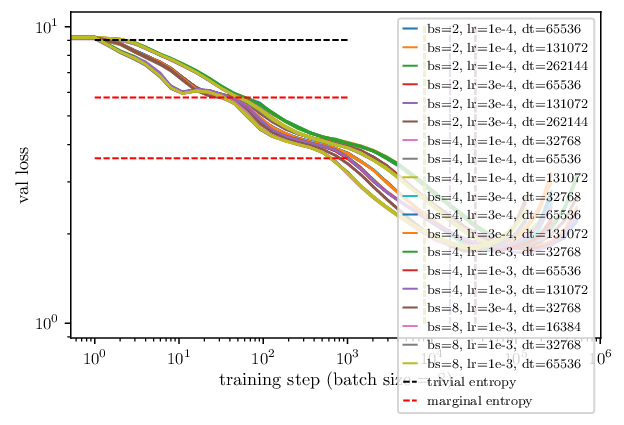

In [3]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 256
P = 16777216
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 12
de = 768

bs = 2
lr = '1e-4'
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
lr = '1e-4'
dt = 131072
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
lr = '1e-4'
dt = 262144
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
lr = '3e-4'
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
lr = '3e-4'
dt = 131072
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 2
lr = '3e-4'
dt = 262144
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-4'
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-4'
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-4'
dt = 131072
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '3e-4'
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '3e-4'
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '3e-4'
dt = 131072
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-3'
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-3'
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '1e-3'
dt = 131072
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '3e-4'
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 16384
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 32768
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '1e-3'
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')


ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{24}$ : bs=2, lr=3e-4, dt=131072 (4 ep)

# $P=2^{26}$

768 2 3e-4 4.0 tensor(1.4506) tensor(0.0086)
768 4 3e-4 4.0 tensor(1.4184) tensor(0.0136)
768 8 3e-4 4.0 tensor(1.4308) tensor(0.0064)
1024 4 3e-4 4.0 tensor(1.4297) tensor(0.0118)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=4$)')

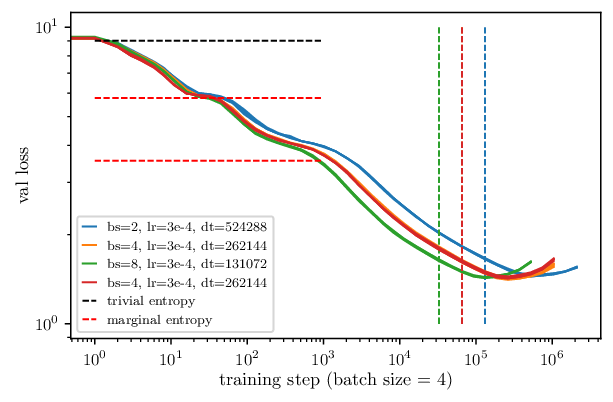

In [4]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 256
P = 67108864
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 12
de = 768

bs = 2
lr = '3e-4'
dt = 524288
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 4
lr = '3e-4'
dt = 262144
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '3e-4'
dt = 131072
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

depth = 12
nh = 16
de = 1024

bs = 4
lr = '3e-4'
dt = 262144
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')



ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.55,3.55], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{26}$ : bs=4, lr=3e-4, dt=262144 (4 ep)

In [ ]:
# TODO: explore around bs=4 with lr and dt

# $P=2^{28}$

1024 4 3e-4 4.0 tensor(1.2365) tensor(0.0015)
1024 8 3e-4 4.0 tensor(1.2201) tensor(0.0136)
1024 16 3e-4 4.0 tensor(1.2219) tensor(0.0119)
torch.Size([8130])
tensor(5.7761)


Text(0.5, 0, 'training step (batch size $=16$)')

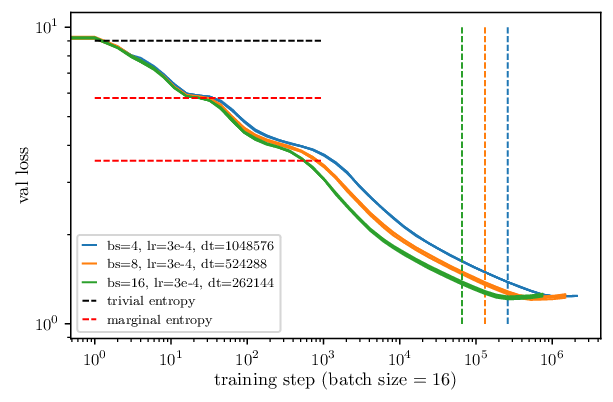

In [5]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1

T = 256
P = 268435456
path = f'tinystories/trained/T{T}/P{P}/'

depth = 12
nh = 16
de = 1024

bs = 4
lr = '3e-4'
dt = 1048576
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 8
lr = '3e-4'
dt = 524288
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

bs = 16
lr = '3e-4'
dt = 262144
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')



ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.55,3.55], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)

# Best at $P=2^{28}$ : bs=8, lr=3e-4, dt=524288 (4 ep)

In [ ]:
# TODO: explore around bs=4 with lr and dt

# ALLSTARS

In [ ]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*5.7, 1*3.6), dpi=120)
custom_lines = []
custom_labels = []


vocab_size = 8192
split = 'train'
i = -1
T = 256

P = 1048576
path = f'tinystories/trained/T{T}/P{P}/'
depth = 12
de = 768
nh = 12

bs = 2
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

P = 4194304
path = f'tinystories/trained/T{T}/P{P}/'
depth = 12
de = 768
nh = 12

bs = 8
lr = '1e-3'
dt = 8192
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

P = 16777216
path = f'tinystories/trained/T{T}/P{P}/'
depth = 12
de = 768
nh = 12

bs = 4
lr = '3e-4'
dt = 65536
dt_ep = dt//(P/(bs*T))
i += 1
prefix = f'tinystories.BPE{vocab_size}_T{T}_P{P}_d{depth}_demb{de}_nh{nh}_bs{bs}_lr{lr}_wt8_dt{dt}'
collection = collect( path, prefix)
mean_loss = []
for entry in collection:

    results = torch.load(path+prefix+entry['ending'])
    dynamics = results['dynamics']
    ax.plot([d['t'] for d in dynamics], [d['val_loss'] for d in dynamics], f'C{i}')
    mean_loss.append(results['best']['loss'])
#     print(T, entry['seed'], min([d['val_loss'] for d in dynamics]), results['best']['loss'], results['best']['step'], dynamics[-1]['t'])
print(de, bs, lr, dt_ep, torch.tensor(mean_loss).mean(), torch.tensor(mean_loss).std())
ax.plot([P//(T*bs),P//(T*bs)], [1e0,1e1], f'C{i}', linestyle='dashed')
custom_lines.append(Line2D([0], [0], color=f'C{i}'))
custom_labels.append(fr'bs={bs}, lr={lr}, dt={dt}')

ax.plot([1e0,1e3],[math.log(8192),math.log(8192)], 'k--')
custom_lines.append(Line2D([0], [0], color='k', linestyle='dashed'))
custom_labels.append(fr'trivial entropy')

marginal = np.load("../SLM/datasets/tinystories/"+f"tinystories.BPE{vocab_size}.{split}_marginal.npy")
marginal = torch.from_numpy(marginal)
marg_ent = torch.masked_select(marginal, (marginal>0))
print(marg_ent.size())
marg_ent = -(marg_ent*marg_ent.log()).sum()
print(marg_ent)
ax.plot([1e0,1e3],[marg_ent.cpu(),marg_ent.cpu()], 'r--')
custom_lines.append(Line2D([0], [0], color='r', linestyle='dashed'))
custom_labels.append(fr'marginal entropy')


ax.plot([1e0,1e3],[3.60,3.60], 'r--')


ax.legend(custom_lines, custom_labels, fontsize=8, handlelength=1)
# ax.set_xlim(1,16)
ax.set_xscale('log')
# ax.set_ylim(1.,5.)
ax.set_yscale('log')

ax.set_ylabel(fr'val loss', fontsize=11)
ax.set_xlabel(fr'training step (batch size $={bs}$)', fontsize=11)